# 03 — Processed Data EDA
## Yale Brain Mets Longitudinal — Post-Preprocessing Quality Check

**What this notebook does:**
1. Scans the HDD output folder and builds a processed-data inventory
2. Checks modality completeness per visit
3. Analyses voxel shapes, spacings, and file sizes
4. Plots per-patient longitudinal timelines
5. Verifies the train / val / test split coverage
6. Examines intensity distributions for all 4 modalities

**Prerequisites:** `02_preprocessing_pipeline.ipynb` must have run at least one 2-hour batch.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import json, re, warnings
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR    = Path("/home/moamed/canada_me/explainable_diseas/implementation")
PROCESSED   = Path("/media/moamed/Data/yale-processed")
INVENTORY   = BASE_DIR / "outputs" / "data_inventory.csv"
SPLITS_JSON = BASE_DIR / "outputs" / "splits.json"
LOG_CSV     = BASE_DIR / "outputs" / "preprocessing_log.csv"

assert PROCESSED.exists(),   f"HDD not mounted!  Mount /dev/sda2 first."
assert INVENTORY.exists(),   "Run notebook 01 first."
assert SPLITS_JSON.exists(), "Run notebook 01 first."

print("✅  All paths OK")
print(f"   Processed root : {PROCESSED}")
print(f"   Inventory CSV  : {INVENTORY}")
print(f"   Splits JSON    : {SPLITS_JSON}")

✅  All paths OK
   Processed root : /media/moamed/Data/yale-processed
   Inventory CSV  : /home/moamed/canada_me/explainable_diseas/implementation/outputs/data_inventory.csv
   Splits JSON    : /home/moamed/canada_me/explainable_diseas/implementation/outputs/splits.json


## 1 · Build Processed Inventory
Scan every `patient/visit/` folder on the HDD and record what modalities exist.

In [2]:
# ── Scan HDD and build processed inventory ───────────────────────────────────
MODALITIES = ["PRE", "POST", "T2", "FLAIR"]

_pat = re.compile(
    r"(?P<patient>YG_\w+)_(?P<date>\d{4}-\d{2}-\d{2})_\d{2}-\d{2}-\d{2}_"
    r"(?P<mod>PRE|POST|T2|FLAIR)_processed\.nii\.gz"
)

records = []
for patient_dir in sorted(PROCESSED.iterdir()):
    if not patient_dir.is_dir():
        continue
    pid = patient_dir.name
    for visit_dir in sorted(patient_dir.iterdir()):
        if not visit_dir.is_dir():
            continue
        vdate = visit_dir.name
        row = {"patient_id": pid, "visit_date": vdate}
        for mod in MODALITIES:
            row[f"has_{mod}"]  = False
            row[f"path_{mod}"] = None
            row[f"size_mb_{mod}"] = np.nan
        for nii in visit_dir.glob("*.nii.gz"):
            m = _pat.match(nii.name)
            if m:
                mod = m.group("mod")
                row[f"has_{mod}"]     = True
                row[f"path_{mod}"]    = str(nii)
                row[f"size_mb_{mod}"] = nii.stat().st_size / 1e6
        row["n_mods"]   = sum(row[f"has_{mod}"] for mod in MODALITIES)
        row["complete"] = all(row[f"has_{mod}"] for mod in MODALITIES)
        records.append(row)

df_proc = pd.DataFrame(records)
print(f"Processed visits found : {len(df_proc)}")
print(f"Complete (all 4 mods)  : {df_proc['complete'].sum()}")
print(f"Unique patients        : {df_proc['patient_id'].nunique()}")
df_proc.head()

Processed visits found : 4356
Complete (all 4 mods)  : 4356
Unique patients        : 976


,patient_id,visit_date,has_PRE,path_PRE,size_mb_PRE,has_POST,path_POST,size_mb_POST,has_T2,path_T2,size_mb_T2,has_FLAIR,path_FLAIR,size_mb_FLAIR,n_mods,complete
0,YG_01M98EKKAR50,2016-11-13,True,/media/moamed/Data/yale-processed/YG_01M98EKKA...,4.678348,True,/media/moamed/Data/yale-processed/YG_01M98EKKA...,5.014728,True,/media/moamed/Data/yale-processed/YG_01M98EKKA...,5.266948,True,/media/moamed/Data/yale-processed/YG_01M98EKKA...,4.939522,4,True
1,YG_021XTGZ9QY91,2016-01-30,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.519093,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,7.100223,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,7.043578,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.945582,4,True
2,YG_021XTGZ9QY91,2016-03-21,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.281612,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.696614,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,7.014857,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.842570,4,True
3,YG_021XTGZ9QY91,2016-08-22,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.162311,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.780348,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.806363,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.574500,4,True
4,YG_021XTGZ9QY91,2016-10-12,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.350499,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.811877,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.868966,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.784329,4,True


In [3]:
# ── Scan HDD and build processed inventory ───────────────────────────────────
MODALITIES = ["PRE", "POST", "T2", "FLAIR"]
# filename pattern:  {patient}_{date}_{time}_{MOD}_processed.nii.gz
_pat = re.compile(r"^(.+?)_(\d{4}-\d{2}-\d{2})_(\d{2}-\d{2}-\d{2})_(\w+)_processed\.nii\.gz$")

records = []
for patient_dir in sorted(PROCESSED.iterdir()):
    if not patient_dir.is_dir():
        continue
    patient_id = patient_dir.name
    for visit_dir in sorted(patient_dir.iterdir()):
        if not visit_dir.is_dir():
            continue
        visit_date = visit_dir.name
        row = {"patient_id": patient_id, "visit_date": visit_date}
        for f in visit_dir.glob("*.nii.gz"):
            m = _pat.match(f.name)
            if m:
                mod = m.group(4)
                row[f"path_{mod}"] = str(f)
                row[f"size_mb_{mod}"] = round(f.stat().st_size / 1e6, 2)
        records.append(row)

df_proc = pd.DataFrame(records)

# ── Derived columns ───────────────────────────────────────────────────────────
for mod in MODALITIES:
    col = f"path_{mod}"
    df_proc[f"has_{mod}"] = df_proc.get(col, pd.Series(dtype=str)).notna()

df_proc["n_mods"]   = df_proc[[f"has_{m}" for m in MODALITIES]].sum(axis=1)
df_proc["complete"] = df_proc["n_mods"] == 4

print(f"Total processed visits : {len(df_proc)}")
print(f"Complete (4 mods)      : {df_proc['complete'].sum()}")
print(f"Partial                : {(~df_proc['complete']).sum()}")
print(f"Unique patients        : {df_proc['patient_id'].nunique()}")
df_proc.head(3)

Total processed visits : 4356
Complete (4 mods)      : 4356
Partial                : 0
Unique patients        : 976


,patient_id,visit_date,path_FLAIR,size_mb_FLAIR,path_POST,size_mb_POST,path_PRE,size_mb_PRE,path_T2,size_mb_T2,has_PRE,has_POST,has_T2,has_FLAIR,n_mods,complete
0,YG_01M98EKKAR50,2016-11-13,/media/moamed/Data/yale-processed/YG_01M98EKKA...,4.94,/media/moamed/Data/yale-processed/YG_01M98EKKA...,5.01,/media/moamed/Data/yale-processed/YG_01M98EKKA...,4.68,/media/moamed/Data/yale-processed/YG_01M98EKKA...,5.27,True,True,True,True,4,True
1,YG_021XTGZ9QY91,2016-01-30,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.95,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,7.10,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.52,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,7.04,True,True,True,True,4,True
2,YG_021XTGZ9QY91,2016-03-21,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.84,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.70,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,6.28,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,7.01,True,True,True,True,4,True


## 2 · Modality Completeness

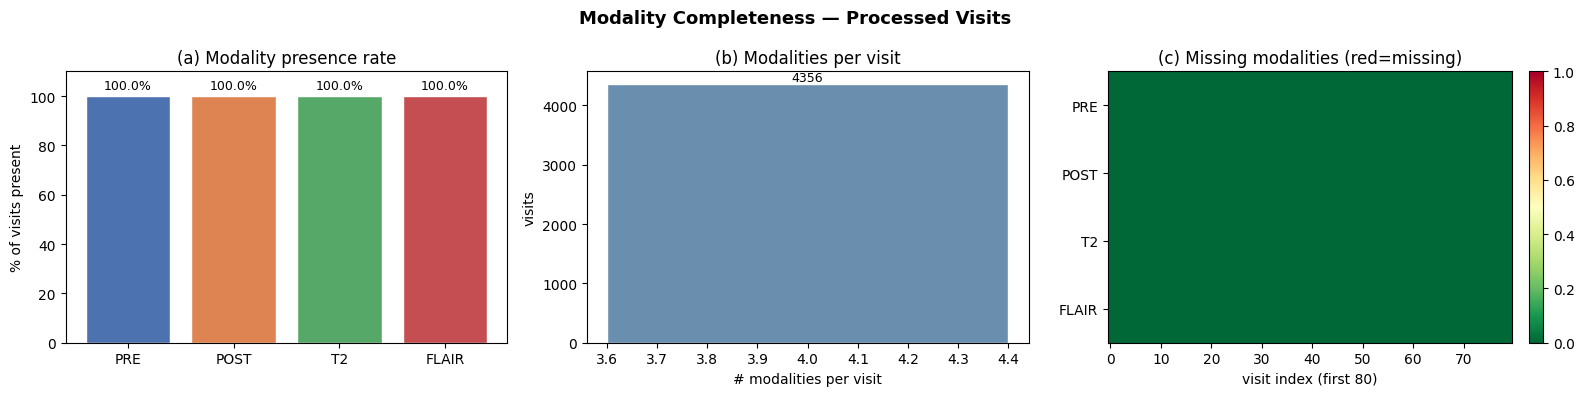


Per-modality counts:
  PRE  : 4356 / 4356  (100.0%)
  POST : 4356 / 4356  (100.0%)
  T2   : 4356 / 4356  (100.0%)
  FLAIR: 4356 / 4356  (100.0%)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Modality Completeness — Processed Visits", fontsize=13, fontweight="bold")

# ── (a) Per-modality presence rate ───────────────────────────────────────────
ax = axes[0]
rates = {m: df_proc[f"has_{m}"].mean() * 100 for m in MODALITIES}
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
bars = ax.bar(rates.keys(), rates.values(), color=colors, edgecolor="white")
ax.set_ylim(0, 110)
ax.set_ylabel("% of visits present")
ax.set_title("(a) Modality presence rate")
for bar, v in zip(bars, rates.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1.5, f"{v:.1f}%",
            ha="center", va="bottom", fontsize=9)

# ── (b) # modalities per visit ────────────────────────────────────────────────
ax = axes[1]
counts = df_proc["n_mods"].value_counts().sort_index()
ax.bar(counts.index, counts.values, color="#6A8EAE", edgecolor="white")
ax.set_xlabel("# modalities per visit")
ax.set_ylabel("visits")
ax.set_title("(b) Modalities per visit")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
for x, y in zip(counts.index, counts.values):
    ax.text(x, y + 2, str(y), ha="center", va="bottom", fontsize=9)

# ── (c) Missing-modality heatmap ──────────────────────────────────────────────
ax = axes[2]
miss = (~df_proc[[f"has_{m}" for m in MODALITIES]]).values.astype(float)
im = ax.imshow(miss[:min(80, len(miss))].T, aspect="auto",
               cmap="RdYlGn_r", vmin=0, vmax=1, interpolation="nearest")
ax.set_yticks(range(4)); ax.set_yticklabels(MODALITIES)
ax.set_xlabel("visit index (first 80)")
ax.set_title("(c) Missing modalities (red=missing)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\nPer-modality counts:")
for m in MODALITIES:
    n = df_proc[f"has_{m}"].sum()
    print(f"  {m:5s}: {n:4d} / {len(df_proc)}  ({n/len(df_proc)*100:.1f}%)")

## 3 · Volume Shape, Spacing & File Size Analysis
Sample 200 visits to measure voxel grids and spacings (fast — just reads NIfTI headers).

In [5]:
# ── Sample headers from complete visits ───────────────────────────────────────
df_complete = df_proc[df_proc["complete"]].copy().reset_index(drop=True)
SAMPLE_N = min(200, len(df_complete))
sample_idx = np.random.RandomState(42).choice(len(df_complete), SAMPLE_N, replace=False)

header_records = []
for i in sample_idx:
    row = df_complete.iloc[i]
    for mod in MODALITIES:
        p = row.get(f"path_{mod}")
        if not p or not Path(p).exists():
            continue
        img = nib.load(p)
        hdr = img.header
        zooms = hdr.get_zooms()[:3]
        shape = img.shape[:3]
        header_records.append({
            "patient_id": row["patient_id"],
            "visit_date": row["visit_date"],
            "modality": mod,
            "sx": shape[0], "sy": shape[1], "sz": shape[2],
            "dx": round(float(zooms[0]), 3),
            "dy": round(float(zooms[1]), 3),
            "dz": round(float(zooms[2]), 3),
            "size_mb": row.get(f"size_mb_{mod}", np.nan),
        })

df_hdr = pd.DataFrame(header_records)
print(f"Header records: {len(df_hdr)}  (from {SAMPLE_N} complete visits × 4 mods)")
df_hdr.groupby("modality")[["sx","sy","sz","dx","dy","dz","size_mb"]].describe().round(2)

Header records: 800  (from 200 complete visits × 4 mods)


sx                                                       sy  \
          count    mean    std    min    25%    50%    75%    max  count   
modality                                                                   
FLAIR     200.0  202.34  20.44  165.0  187.0  196.0  220.0  250.0  200.0   
POST      200.0  202.34  20.44  165.0  187.0  196.0  220.0  250.0  200.0   
PRE       200.0  202.34  20.44  165.0  187.0  196.0  220.0  250.0  200.0   
T2        200.0  202.34  20.44  165.0  187.0  196.0  220.0  250.0  200.0   

                  ...   dz      size_mb                                      \
            mean  ...  75%  max   count  mean   std   min   25%   50%   75%   
modality          ...                                                         
FLAIR     228.88  ...  1.0  1.0   200.0  5.65  0.56  4.47  5.28  5.62  6.02   
POST      228.88  ...  1.0  1.0   200.0  5.73  0.56  4.07  5.30  5.70  6.09   
PRE       228.88  ...  1.0  1.0   200.0  5.30  0.53  3.83  4.91  5.28  5.68   
T2        228.88  ...  1.0  1.0   200.0  5.83  0.53  4.75  5.46  5.82  6.21   

                
           max  
modality        
FLAIR     7.24  
POST      7.33  
PRE       6.78  
T2        7.29  

[4 rows x 56 columns]

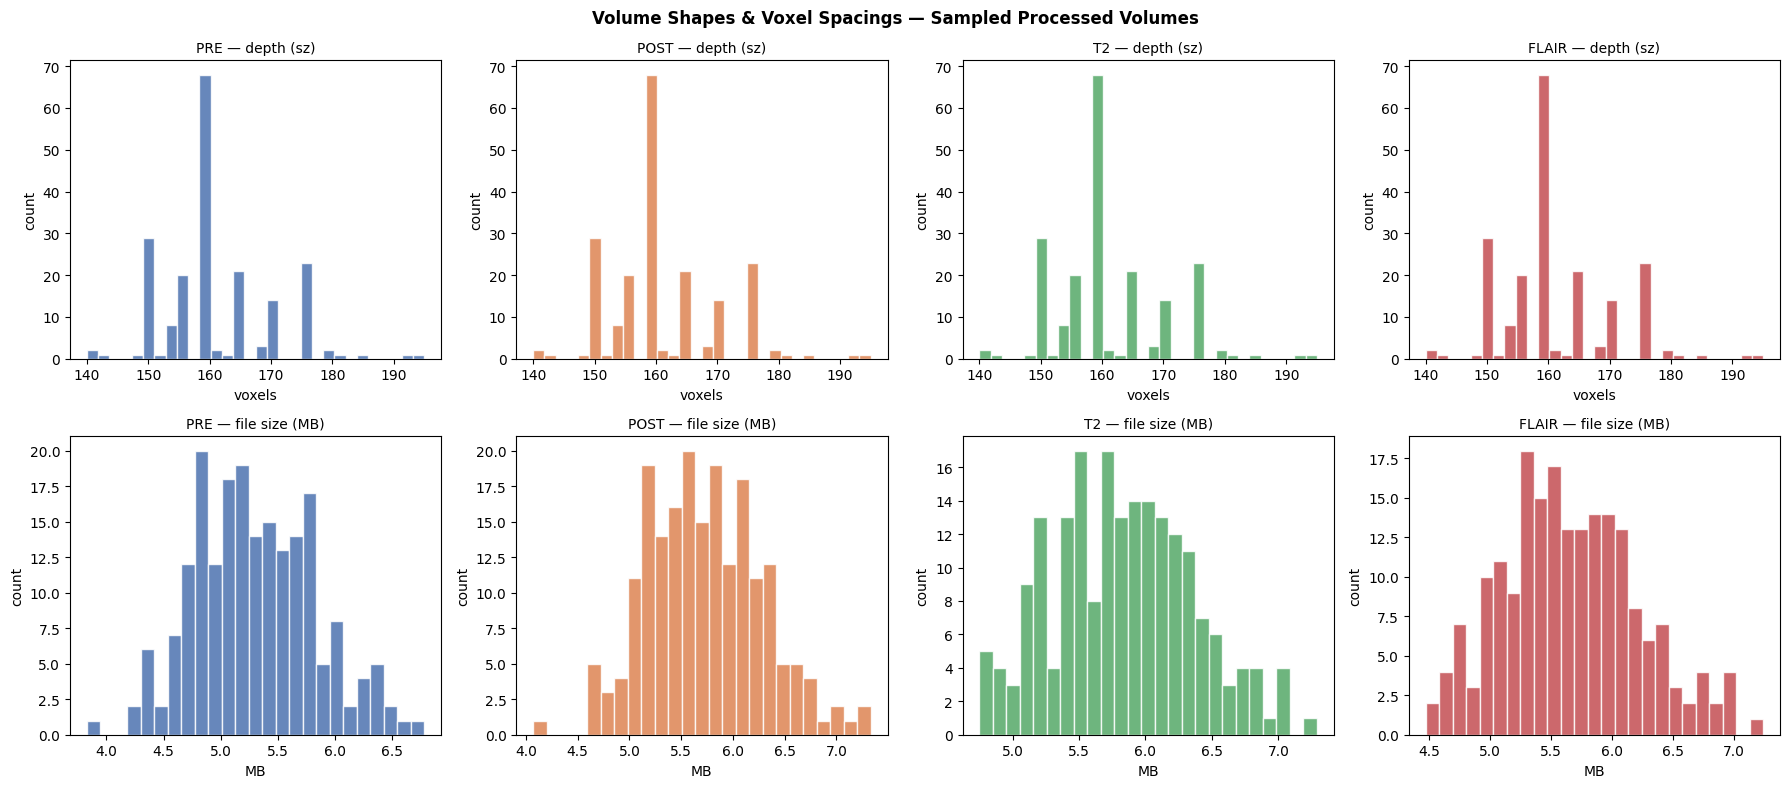


Spacing sanity check (should be 1.0 mm³ after resampling):
           dx             dy             dz          
          min  max mean  min  max mean  min  max mean
modality                                             
FLAIR     1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0
POST      1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0
PRE       1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0
T2        1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0


In [6]:
# ── Shape & spacing plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Volume Shapes & Voxel Spacings — Sampled Processed Volumes", fontsize=12, fontweight="bold")

MOD_COLORS = {"PRE": "#4C72B0", "POST": "#DD8452", "T2": "#55A868", "FLAIR": "#C44E52"}

for col_i, mod in enumerate(MODALITIES):
    sub = df_hdr[df_hdr["modality"] == mod]
    c = MOD_COLORS[mod]

    # Row 0: volume shape (smallest dim = depth typically)
    ax = axes[0, col_i]
    ax.hist(sub["sz"], bins=30, color=c, alpha=0.85, edgecolor="white")
    ax.set_title(f"{mod} — depth (sz)", fontsize=10)
    ax.set_xlabel("voxels"); ax.set_ylabel("count")

    # Row 1: file size
    ax = axes[1, col_i]
    ax.hist(sub["size_mb"], bins=25, color=c, alpha=0.85, edgecolor="white")
    ax.set_title(f"{mod} — file size (MB)", fontsize=10)
    ax.set_xlabel("MB"); ax.set_ylabel("count")

plt.tight_layout()
plt.show()

# ── Spacing sanity check (should be all 1×1×1 after resampling) ───────────────
print("\nSpacing sanity check (should be 1.0 mm³ after resampling):")
print(df_hdr.groupby("modality")[["dx","dy","dz"]].agg(["min","max","mean"]).round(4))

## 4 · Intensity Distribution (PRE / POST / T2 / FLAIR)
Load a small random sample of volumes and compute per-modality intensity statistics.

In [7]:
# ── Load 50 volumes per modality and collect intensity stats ──────────────────
INTENSITY_N = min(50, len(df_complete))
int_idx = np.random.RandomState(0).choice(len(df_complete), INTENSITY_N, replace=False)

intensity_stats = {mod: {"mean": [], "std": [], "p1": [], "p99": [], "flat_sample": []} for mod in MODALITIES}

for i in int_idx:
    row = df_complete.iloc[i]
    for mod in MODALITIES:
        p = row.get(f"path_{mod}")
        if not p or not Path(p).exists():
            continue
        arr = nib.load(p).get_fdata(dtype=np.float32).ravel()
        arr = arr[arr != 0]                  # ignore background
        if len(arr) == 0:
            continue
        intensity_stats[mod]["mean"].append(arr.mean())
        intensity_stats[mod]["std"].append(arr.std())
        intensity_stats[mod]["p1"].append(np.percentile(arr, 1))
        intensity_stats[mod]["p99"].append(np.percentile(arr, 99))
        # subsample for histogram
        sub = arr[np.random.RandomState(42).randint(0, len(arr), min(5000, len(arr)))]
        intensity_stats[mod]["flat_sample"].extend(sub.tolist())

print("Collected intensity samples:")
for mod in MODALITIES:
    n = len(intensity_stats[mod]["mean"])
    print(f"  {mod:5s}: {n} volumes  →  mean={np.mean(intensity_stats[mod]['mean']):.3f} ± {np.mean(intensity_stats[mod]['std']):.3f}")

Collected intensity samples:
  PRE  : 50 volumes  →  mean=1.863 ± 0.789
  POST : 50 volumes  →  mean=1.728 ± 0.893
  T2   : 50 volumes  →  mean=1.559 ± 1.214
  FLAIR: 50 volumes  →  mean=1.708 ± 1.012


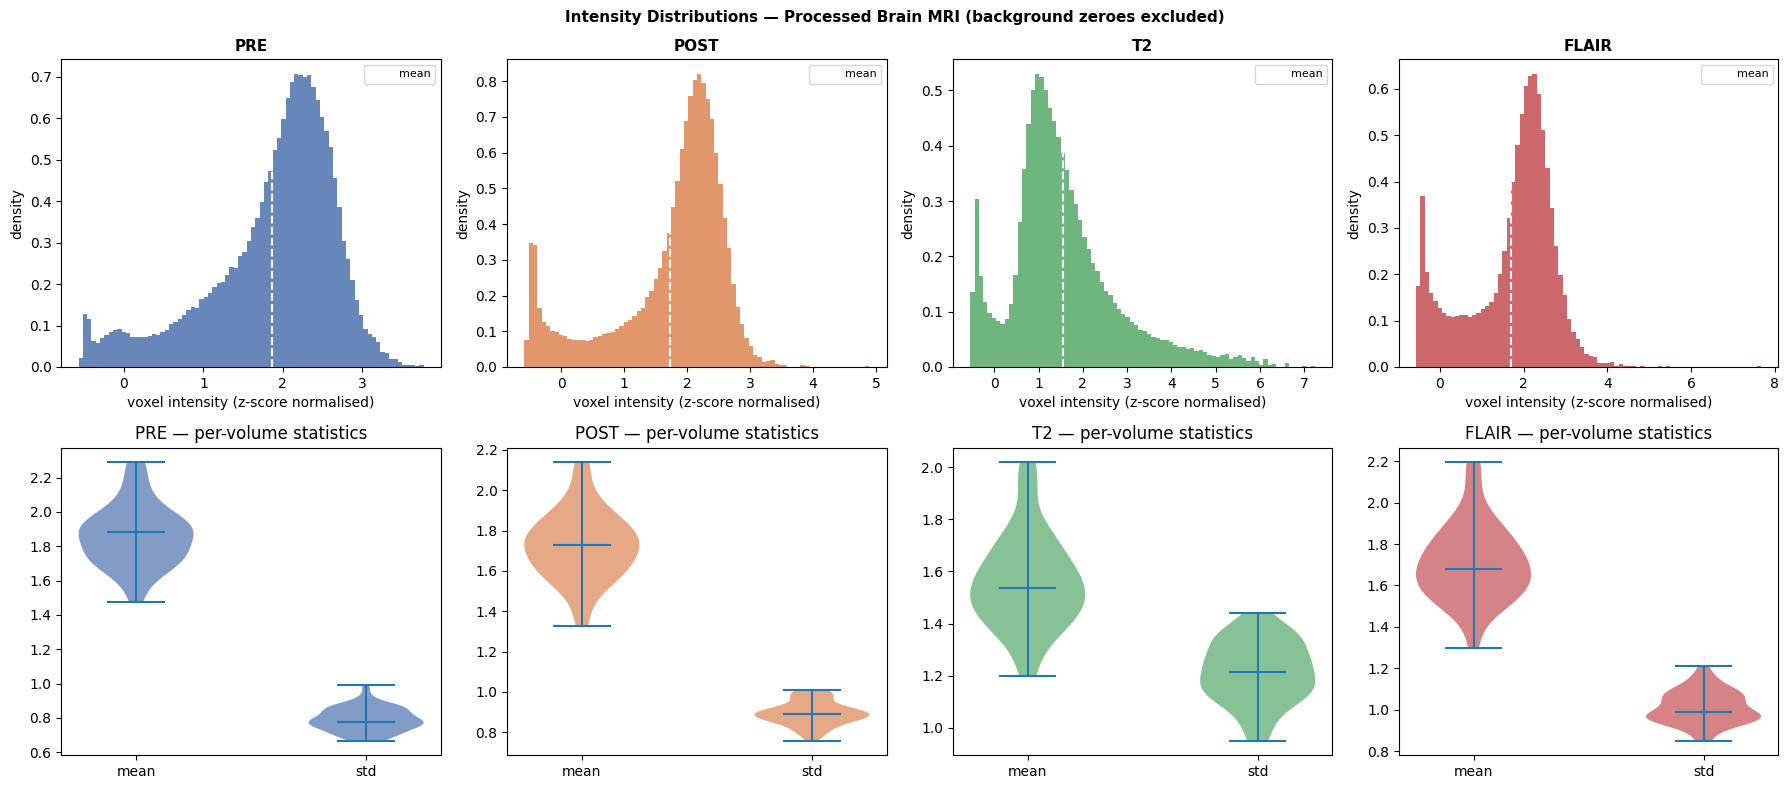

In [8]:
# ── Intensity histograms + per-modality mean/std box ─────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Intensity Distributions — Processed Brain MRI (background zeroes excluded)", fontsize=11, fontweight="bold")

for col_i, mod in enumerate(MODALITIES):
    c = MOD_COLORS[mod]
    s = intensity_stats[mod]
    flat = np.array(s["flat_sample"])

    # Row 0: intensity histogram
    ax = axes[0, col_i]
    ax.hist(flat, bins=80, color=c, alpha=0.85, edgecolor="none", density=True)
    ax.axvline(np.mean(s["mean"]), color="white", lw=1.5, ls="--", label="mean")
    ax.set_title(f"{mod}", fontsize=11, fontweight="bold")
    ax.set_xlabel("voxel intensity (z-score normalised)")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)

    # Row 1: per-volume mean ± std violin
    ax = axes[1, col_i]
    data = [s["mean"], s["std"]]
    vp = ax.violinplot(data, positions=[0, 1], showmedians=True, widths=0.5)
    for body in vp["bodies"]:
        body.set_facecolor(c); body.set_alpha(0.7)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["mean", "std"])
    ax.set_title(f"{mod} — per-volume statistics")

plt.tight_layout()
plt.show()

## 5 · Visual Slice Inspection
Show axial / coronal / sagittal centre slices for 6 random complete visits.

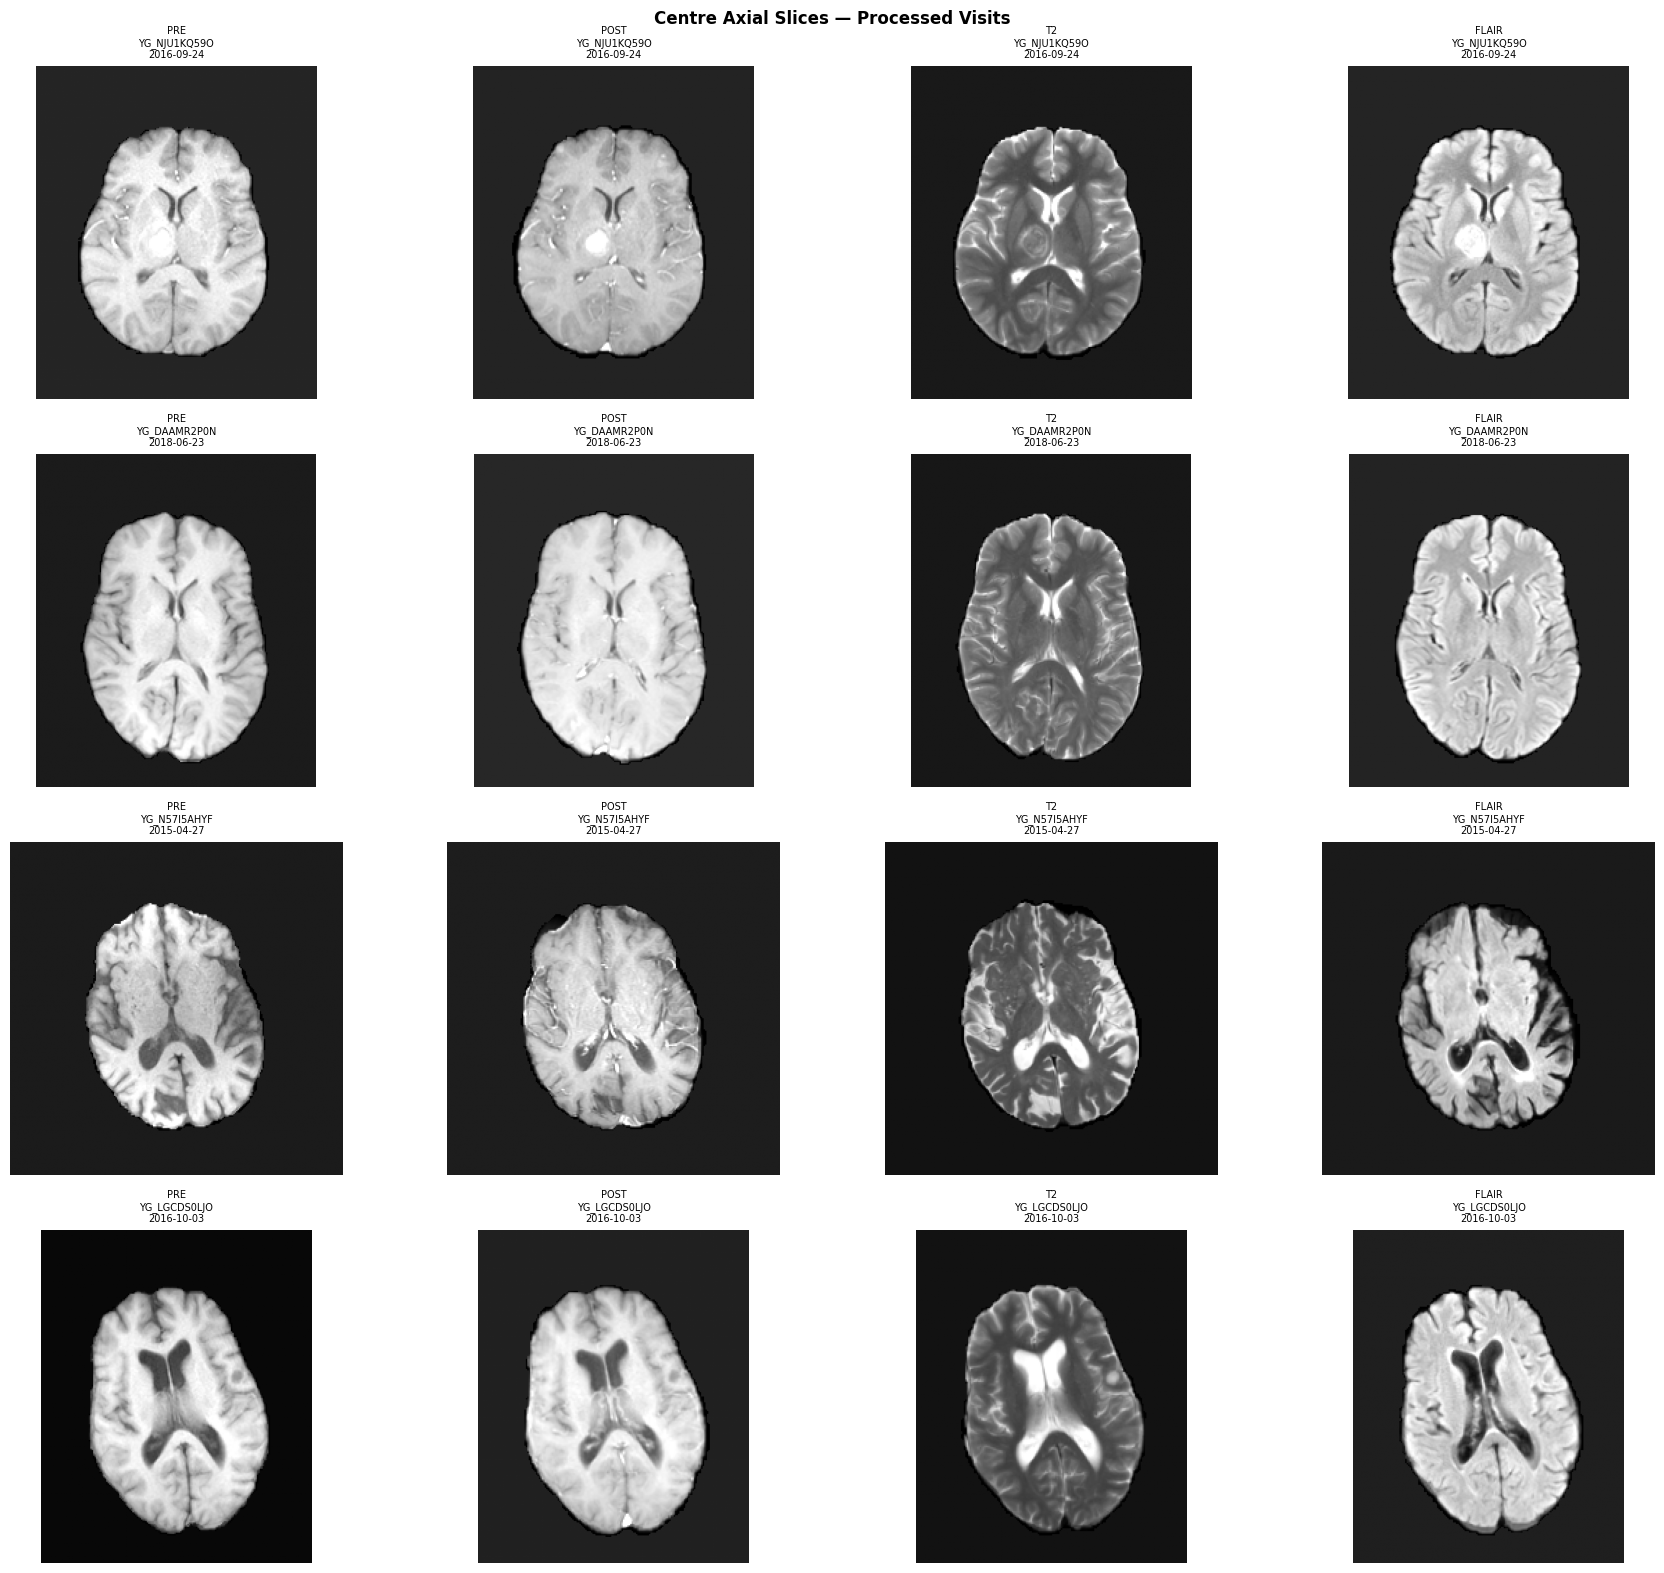

In [9]:
SHOW_VISITS = 4                # how many visits to show
rng = np.random.RandomState(7)
vis_idx = rng.choice(len(df_complete), SHOW_VISITS, replace=False)

fig, big_axes = plt.subplots(SHOW_VISITS, 4, figsize=(18, SHOW_VISITS * 4))
fig.suptitle("Centre Axial Slices — Processed Visits", fontsize=12, fontweight="bold")

for row_i, vi in enumerate(vis_idx):
    vrow = df_complete.iloc[vi]
    pid = vrow["patient_id"]; vd = vrow["visit_date"]
    for col_i, mod in enumerate(MODALITIES):
        ax = big_axes[row_i, col_i]
        p = vrow.get(f"path_{mod}")
        if p and Path(p).exists():
            vol = nib.load(p).get_fdata(dtype=np.float32)
            sl  = vol[:, :, vol.shape[2] // 2]
            vmin, vmax = np.percentile(sl[sl != 0], [1, 99]) if sl.any() else (0, 1)
            ax.imshow(np.rot90(sl), cmap="gray", vmin=vmin, vmax=vmax)
            ax.set_title(f"{mod}\n{pid[:12]}\n{vd}", fontsize=7)
        else:
            ax.set_facecolor("#333")
            ax.text(0.5, 0.5, "MISSING", transform=ax.transAxes,
                    ha="center", va="center", color="red", fontsize=10)
        ax.axis("off")

plt.tight_layout()
plt.show()

## 6 · Longitudinal Timeline per Patient
How many processed visits does each patient have? What is the time spread?

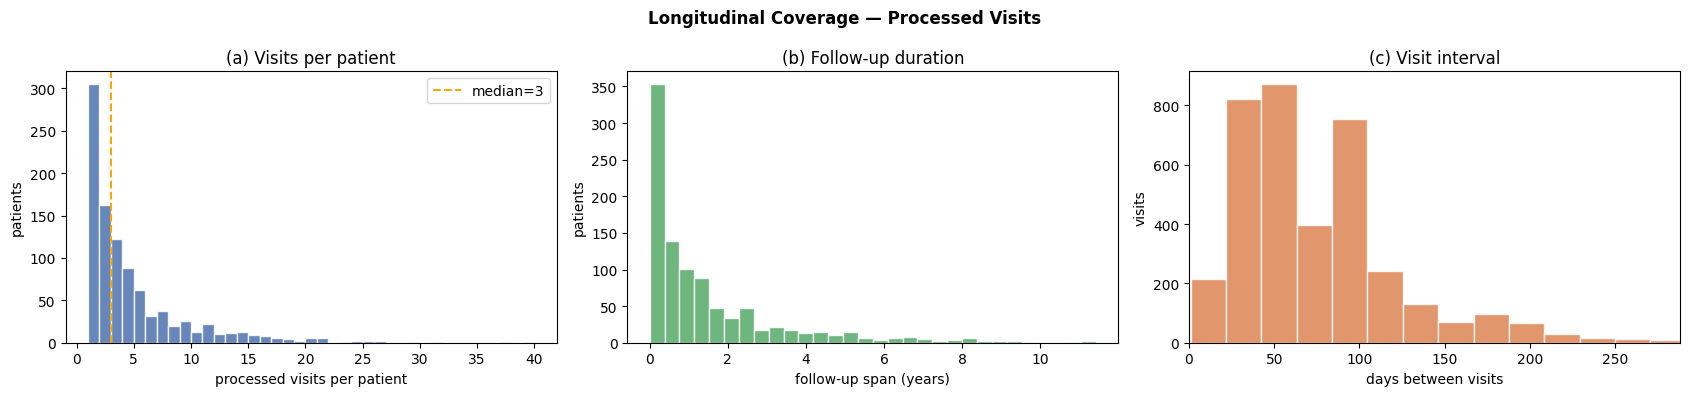


Patients with ≥2 processed complete visits : 671
Total processed complete visits             : 4356


In [10]:
# ── Merge with raw inventory to get days_since_baseline ───────────────────────
df_raw = pd.read_csv(INVENTORY)
df_raw["visit_date"] = df_raw["visit_date"].astype(str)
df_proc["visit_date"] = df_proc["visit_date"].astype(str)

df_merged = df_proc.merge(
    df_raw[["patient_id","visit_date","days_since_baseline","interval_days","training_usability"]],
    on=["patient_id","visit_date"], how="left"
)

# ── Visits per patient distribution ──────────────────────────────────────────
visits_per_pt = df_merged.groupby("patient_id").size()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle("Longitudinal Coverage — Processed Visits", fontsize=12, fontweight="bold")

ax = axes[0]
ax.hist(visits_per_pt.values, bins=range(1, visits_per_pt.max() + 2),
        color="#4C72B0", edgecolor="white", alpha=0.85)
ax.set_xlabel("processed visits per patient")
ax.set_ylabel("patients")
ax.set_title("(a) Visits per patient")
ax.axvline(visits_per_pt.median(), color="orange", ls="--", lw=1.5, label=f"median={visits_per_pt.median():.0f}")
ax.legend()

# ── Follow-up duration ────────────────────────────────────────────────────────
ax = axes[1]
pt_span = df_merged.groupby("patient_id")["days_since_baseline"].max().dropna()
ax.hist(pt_span.values / 365, bins=30, color="#55A868", edgecolor="white", alpha=0.85)
ax.set_xlabel("follow-up span (years)")
ax.set_ylabel("patients")
ax.set_title("(b) Follow-up duration")

# ── Interval between consecutive visits ──────────────────────────────────────
ax = axes[2]
intervals = df_merged["interval_days"].dropna()
ax.hist(intervals.values, bins=50, color="#DD8452", edgecolor="white", alpha=0.85)
ax.set_xlabel("days between visits")
ax.set_ylabel("visits")
ax.set_title("(c) Visit interval")
ax.set_xlim(0, intervals.quantile(0.98))

plt.tight_layout()
plt.show()

print(f"\nPatients with ≥2 processed complete visits : "
      f"{(df_merged[df_merged['complete']].groupby('patient_id').size() >= 2).sum()}")
print(f"Total processed complete visits             : {df_merged['complete'].sum()}")

## 7 · Train / Val / Test Split Coverage
Check what fraction of each split has already been processed.

split  patients_total  patients_processed  patient_coverage_%  full_visits_total  full_visits_processed  visit_coverage_%
train            1144                 783                68.4               3482                   3477              99.9
  val             143                  92                64.3                441                    441             100.0
 test             143                 101                70.6                441                    438              99.3


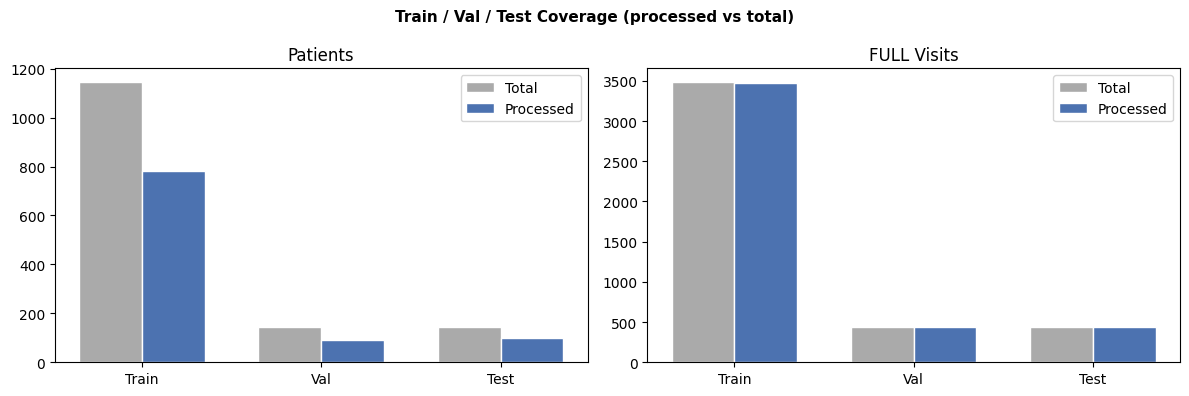

In [11]:
with open(SPLITS_JSON) as f:
    splits_data = json.load(f)

split_map = {}
for sp in ["train", "val", "test"]:
    for pid in splits_data[sp]:
        split_map[pid] = sp

df_merged["split"] = df_merged["patient_id"].map(split_map).fillna("unknown")

# ── Per-split coverage ────────────────────────────────────────────────────────
split_report = []
for sp in ["train", "val", "test"]:
    total_pts    = len(splits_data[sp])
    proc_pts     = df_merged[df_merged["split"] == sp]["patient_id"].nunique()
    total_visits = len(df_raw[df_raw["patient_id"].isin(splits_data[sp]) &
                               (df_raw["training_usability"] == "FULL")])
    proc_visits  = df_merged[(df_merged["split"] == sp) & df_merged["complete"]].shape[0]
    split_report.append({
        "split": sp,
        "patients_total": total_pts,
        "patients_processed": proc_pts,
        "patient_coverage_%": round(proc_pts / total_pts * 100, 1),
        "full_visits_total": total_visits,
        "full_visits_processed": proc_visits,
        "visit_coverage_%": round(proc_visits / max(1, total_visits) * 100, 1),
    })

df_sr = pd.DataFrame(split_report)
print(df_sr.to_string(index=False))

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Train / Val / Test Coverage (processed vs total)", fontsize=11, fontweight="bold")
x = np.arange(3); labels = ["Train", "Val", "Test"]; w = 0.35

for ax, total_col, proc_col, title in [
    (axes[0], "patients_total", "patients_processed", "Patients"),
    (axes[1], "full_visits_total", "full_visits_processed", "FULL Visits"),
]:
    ax.bar(x - w/2, df_sr[total_col], w, label="Total", color="#AAAAAA", edgecolor="white")
    ax.bar(x + w/2, df_sr[proc_col],  w, label="Processed", color="#4C72B0", edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_title(title); ax.legend()

plt.tight_layout()
plt.show()

## 8 · Save Processed Manifest CSV
Export a clean CSV: `patient_id, visit_date, split, complete, path_PRE, path_POST, path_T2, path_FLAIR`  
This is the **input manifest for the CNN notebook**.

In [12]:
manifest_cols = ["patient_id", "visit_date", "split", "complete",
                 "path_PRE", "path_POST", "path_T2", "path_FLAIR",
                 "n_mods", "days_since_baseline", "interval_days"]

df_manifest = df_merged[manifest_cols].copy()

# ── Only keep rows where the processed files actually exist ───────────────────
def _exists(p):
    return isinstance(p, str) and Path(p).exists()

path_cols = ["path_PRE", "path_POST", "path_T2", "path_FLAIR"]
for col in path_cols:
    df_manifest[col] = df_manifest[col].where(df_manifest[col].apply(_exists))

MANIFEST_PATH = BASE_DIR / "outputs" / "processed_manifest.csv"
df_manifest.to_csv(MANIFEST_PATH, index=False)
print(f"✅  Manifest saved → {MANIFEST_PATH}")
print(f"   Total rows       : {len(df_manifest)}")
print(f"   Complete visits  : {df_manifest['complete'].sum()}")
print(f"\nPer-split complete visits:")
print(df_manifest[df_manifest["complete"]].groupby("split").size().to_string())
df_manifest.head()

✅  Manifest saved → /home/moamed/canada_me/explainable_diseas/implementation/outputs/processed_manifest.csv
   Total rows       : 4356
   Complete visits  : 4356

Per-split complete visits:
split
test      438
train    3477
val       441


,patient_id,visit_date,split,complete,path_PRE,path_POST,path_T2,path_FLAIR,n_mods,days_since_baseline,interval_days
0,YG_01M98EKKAR50,2016-11-13,train,True,/media/moamed/Data/yale-processed/YG_01M98EKKA...,/media/moamed/Data/yale-processed/YG_01M98EKKA...,/media/moamed/Data/yale-processed/YG_01M98EKKA...,/media/moamed/Data/yale-processed/YG_01M98EKKA...,4,0,NaN
1,YG_021XTGZ9QY91,2016-01-30,train,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,4,0,NaN
2,YG_021XTGZ9QY91,2016-03-21,train,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,4,51,42.0
3,YG_021XTGZ9QY91,2016-08-22,train,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,4,205,33.0
4,YG_021XTGZ9QY91,2016-10-12,train,True,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,/media/moamed/Data/yale-processed/YG_021XTGZ9Q...,4,256,42.0
